--- Loading Data ---


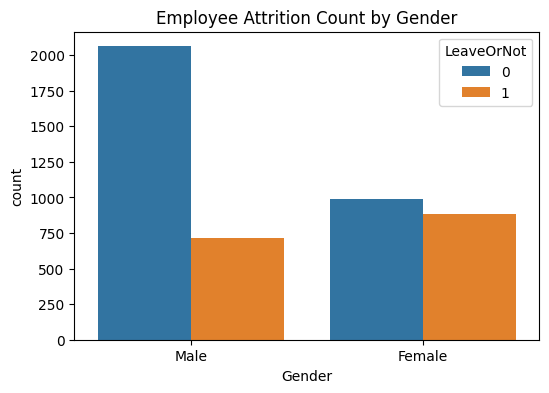

--- Preprocessing Categorical Features ---
--- Training Models ---

=== Model Comparison Table ===
| Algorithm         |   Accuracy |   Precision |   Recall |   F1-Score |
|:------------------|-----------:|------------:|---------:|-----------:|
| Decision Tree     |     0.84   |      0.7867 |   0.7352 |     0.7601 |
| Random Forest     |     0.8668 |      0.9264 |   0.6667 |     0.7754 |
| Gradient Boosting |     0.8604 |      0.8835 |   0.6854 |     0.7719 |

--- Plotting Feature Importance ---


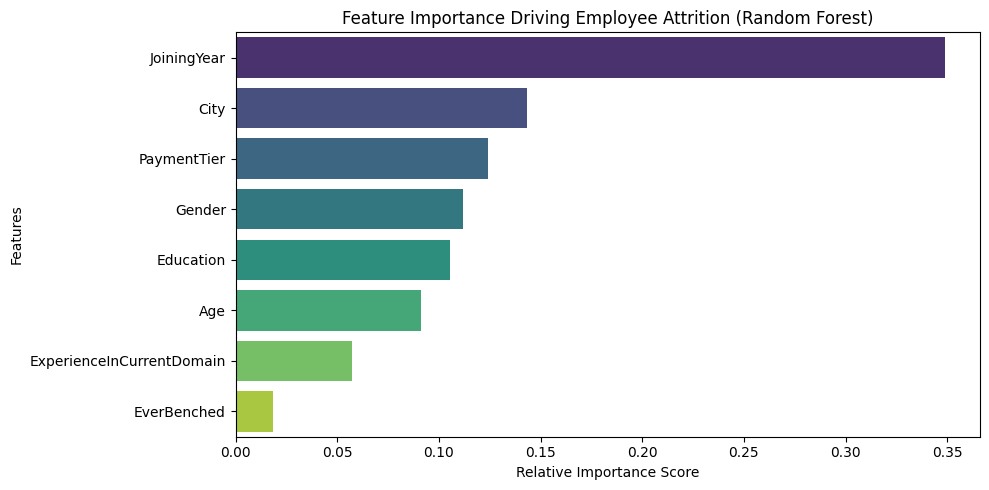


[SUCCESS] Saved Random Forest model as 'best_employee_model.pkl'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1. DATA LOADING & EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("--- Loading Data ---")
data = pd.read_csv("Employee.csv")

# Simple EDA Visual
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="Gender", hue="LeaveOrNot")
plt.title("Employee Attrition Count by Gender")
plt.show()

# ==========================================
# 2. DATA PREPROCESSING (Done Once!)
# ==========================================
print("--- Preprocessing Categorical Features ---")
le = LabelEncoder()
categorical_cols = ["Education", "City", "Gender", "EverBenched"]

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Feature-Target Split
X = data.drop("LeaveOrNot", axis=1)
y = data["LeaveOrNot"]

# Train-Test Split (Exactly Once)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. MODEL TRAINING & EVALUATION
# ==========================================
print("--- Training Models ---")

# Define our candidate models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

# Dictionary to hold performance metrics
results = []

for name, model in models.items():
    # Fit
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Algorithm": name,
        "Accuracy": f"{acc:.4f}",
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}",
        "F1-Score": f"{f1:.4f}"
    })

# Display Model Comparison Table
df_results = pd.DataFrame(results)
print("\n=== Model Comparison Table ===")
print(df_results.to_markdown(index=False))

# ==========================================
# 4. ADDING FEATURE IMPORTANCE (New Requirement)
# ==========================================
print("\n--- Plotting Feature Importance ---")
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=X.columns[indices], hue=X.columns[indices], palette="viridis", legend=False)
plt.title("Feature Importance Driving Employee Attrition (Random Forest)")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# ==========================================
# 5. SAVE THE BEST MODEL
# ==========================================
# Saving Random Forest since it hit the highest accuracy (~86.68%)
joblib.dump(models["Random Forest"], "best_employee_model.pkl")
print("\n[SUCCESS] Saved Random Forest model as 'best_employee_model.pkl'")